<a href="https://colab.research.google.com/github/RaghadDasman/Parallel-Computing-copy/blob/main/Raghad_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

url = 'https://raw.githubusercontent.com/AbdulrahmanB-25/Machine_Learning_Competition/refs/heads/main/Riyadh_Master_Dataset.csv'

# Load the dataset
df = pd.read_csv(url)

# Preview the data
df.head()

,neighborhood,property_id,price,area,category,lat,lng,dining_cafe,med_facilities,health_retail,...,pedestrian,resort_rural_retreats,gov_civil,malls_shopping,Fiber_Available,FWA_Available,Mobile_Available,connectivity_score,bus_count,metro_count
0,2nd Industrial City,1,4500.0,160.0,1,24.557812,46.862682,46,2,1,...,0,0,9,4,0.0,1.0,1.0,2.0,53,0
1,2nd Industrial City,2,17000.0,150.0,1,24.548426,46.866436,46,2,1,...,0,0,9,4,0.0,1.0,1.0,2.0,53,0
2,2nd Industrial City,3,1500000.0,750.0,2,24.555798,46.860222,46,2,1,...,0,0,9,4,0.0,1.0,1.0,2.0,53,0
3,2nd Industrial City,4,1000000.0,600.0,2,24.557178,46.864990,46,2,1,...,0,0,9,4,0.0,1.0,1.0,2.0,53,0
4,2nd Industrial City,5,1200000.0,600.0,2,24.554862,46.861086,46,2,1,...,0,0,9,4,0.0,1.0,1.0,2.0,53,0


In [ ]:
df.shape

(345723, 27)

In [ ]:
df.columns

Index(['neighborhood', 'property_id', 'price', 'area', 'category', 'lat',
       'lng', 'dining_cafe', 'med_facilities', 'health_retail', 'fitness_care',
       'edu_primary', 'edu_higher', 'religious', 'essential_retail',
       'parks_green', 'sports_play', 'pedestrian', 'resort_rural_retreats',
       'gov_civil', 'malls_shopping', 'Fiber_Available', 'FWA_Available',
       'Mobile_Available', 'connectivity_score', 'bus_count', 'metro_count'],
      dtype='object')

In [ ]:
df_neigh = df.groupby("neighborhood").agg({
    "price": "mean",
    "area": "mean",
    "lat": "mean",
    "lng": "mean",

    "dining_cafe": "mean",
    "med_facilities": "mean",
    "health_retail": "mean",
    "fitness_care": "mean",
    "edu_primary": "mean",
    "edu_higher": "mean",
    "religious": "mean",
    "essential_retail": "mean",
    "parks_green": "mean",
    "sports_play": "mean",
    "pedestrian": "mean",
    "resort_rural_retreats": "mean",
    "gov_civil": "mean",
    "malls_shopping": "mean",

    "Fiber_Available": "mean",
    "FWA_Available": "mean",
    "Mobile_Available": "mean",
    "connectivity_score": "mean",

    "bus_count": "mean",
    "metro_count": "mean"
}).reset_index()

In [ ]:
df_neigh.shape

(176, 25)

In [ ]:
df_neigh.head()

,neighborhood,price,area,lat,lng,dining_cafe,med_facilities,health_retail,fitness_care,edu_primary,...,pedestrian,resort_rural_retreats,gov_civil,malls_shopping,Fiber_Available,FWA_Available,Mobile_Available,connectivity_score,bus_count,metro_count
0,2nd Industrial City,8.632149e+05,497.808511,24.554323,46.869531,46.0,2.0,1.0,0.0,1.0,...,0.0,0.0,9.0,4.0,0.0,1.0,1.0,2.0,53.0,0.0
1,Al Amal Dist.,1.074875e+06,289.957895,24.645098,46.723189,23.0,1.0,0.0,0.0,0.0,...,0.0,0.0,2.0,1.0,0.0,1.0,1.0,2.0,5.0,0.0
2,Al Ammajiyah Dist.,1.200000e+05,320.000000,24.441914,46.977177,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
3,Al Andalus Dist.,1.726945e+06,411.036232,24.744570,46.787372,61.0,4.0,3.0,5.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,1.0,2.0,25.0,0.0
4,Al Aqeeq Dist.,2.144721e+06,352.435218,24.778786,46.626886,167.0,4.0,5.0,0.0,0.0,...,0.0,0.0,0.0,2.0,1.0,1.0,1.0,3.0,28.0,1.0


In [ ]:
service_cols = [
    "dining_cafe",
    "med_facilities",
    "health_retail",
    "fitness_care",
    "edu_primary",
    "edu_higher",
    "religious",
    "essential_retail",
    "parks_green",
    "sports_play",
    "pedestrian",
    "resort_rural_retreats",
    "gov_civil",
    "malls_shopping"
]

In [ ]:
scaler = MinMaxScaler()

df_neigh[service_cols] = scaler.fit_transform(df_neigh[service_cols])

In [ ]:
df_neigh["services_score"] = df_neigh[service_cols].mean(axis=1)

In [ ]:
df_neigh[["neighborhood", "services_score"]].head()

,neighborhood,services_score
0,2nd Industrial City,0.111895
1,Al Amal Dist.,0.035639
2,Al Ammajiyah Dist.,0.000000
3,Al Andalus Dist.,0.132631
4,Al Aqeeq Dist.,0.085761


In [ ]:
transport_cols = ["bus_count", "metro_count"]

In [ ]:
scaler = MinMaxScaler()

df_neigh[transport_cols] = scaler.fit_transform(df_neigh[transport_cols])

In [ ]:
df_neigh["transport_score"] = df_neigh[transport_cols].mean(axis=1)

In [ ]:
scaler = MinMaxScaler()

df_neigh["connectivity_score_scaled"] = scaler.fit_transform(
    df_neigh[["connectivity_score"]]
)

In [ ]:
df_neigh[[
    "neighborhood",
    "transport_score",
    "connectivity_score_scaled"
]].head()

,neighborhood,transport_score,connectivity_score_scaled
0,2nd Industrial City,0.301136,0.5
1,Al Amal Dist.,0.028409,0.5
2,Al Ammajiyah Dist.,0.000000,0.0
3,Al Andalus Dist.,0.142045,0.5
4,Al Aqeeq Dist.,0.259091,1.0


In [ ]:
df_neigh["price_log"] = np.log1p(df_neigh["price"])

In [ ]:
scaler = MinMaxScaler()

df_neigh["price_score"] = scaler.fit_transform(df_neigh[["price_log"]])

In [ ]:
df_neigh["final_score"] = (
    0.40 * df_neigh["services_score"] +
    0.30 * df_neigh["connectivity_score_scaled"] +
    0.20 * df_neigh["transport_score"] +
    0.10 * df_neigh["price_score"]
)

In [ ]:
df_neigh[[
    "neighborhood",
    "services_score",
    "transport_score",
    "connectivity_score_scaled",
    "price_score",
    "final_score"
]].head()

,neighborhood,services_score,transport_score,connectivity_score_scaled,price_score,final_score
0,2nd Industrial City,0.111895,0.301136,0.5,0.700326,0.325018
1,Al Amal Dist.,0.035639,0.028409,0.5,0.749502,0.244888
2,Al Ammajiyah Dist.,0.000000,0.000000,0.0,0.257856,0.025786
3,Al Andalus Dist.,0.132631,0.142045,0.5,0.855827,0.317044
4,Al Aqeeq Dist.,0.085761,0.259091,1.0,0.904411,0.476564


In [ ]:
q1 = df_neigh["final_score"].quantile(0.33)
q2 = df_neigh["final_score"].quantile(0.66)

In [ ]:
def assign_class(score):
    if score <= q1:
        return "Low"
    elif score <= q2:
        return "Medium"
    return "High"

df_neigh["neighborhood_class"] = df_neigh["final_score"].apply(assign_class)

In [ ]:
df_neigh["neighborhood_class"].value_counts()

,count
neighborhood_class,
High,62
Medium,57
Low,57


In [ ]:
df_neigh[[
    "neighborhood",
    "final_score",
    "neighborhood_class"
]].head()

,neighborhood,final_score,neighborhood_class
0,2nd Industrial City,0.325018,Medium
1,Al Amal Dist.,0.244888,Low
2,Al Ammajiyah Dist.,0.025786,Low
3,Al Andalus Dist.,0.317044,Medium
4,Al Aqeeq Dist.,0.476564,High


In [ ]:
user_budget = 1500000

user_preferences = {
    "cafes": 1,
    "parks": 1,
    "schools": 1,
    "fiber": 1,
    "metro": 0
}

In [ ]:
df_neigh["budget_fit"] = 1 - (df_neigh["price"] / user_budget)
df_neigh["budget_fit"] = df_neigh["budget_fit"].clip(0, 1)

In [ ]:
df_neigh["cafes_fit"] = df_neigh["dining_cafe"] * user_preferences["cafes"]
df_neigh["parks_fit"] = df_neigh["parks_green"] * user_preferences["parks"]
df_neigh["schools_fit"] = (
    (df_neigh["edu_primary"] + df_neigh["edu_higher"]) / 2
) * user_preferences["schools"]

In [ ]:
df_neigh["fiber_fit"] = df_neigh["Fiber_Available"] * user_preferences["fiber"]
df_neigh["metro_fit"] = df_neigh["metro_count"] * user_preferences["metro"]

In [ ]:
df_neigh["match_score"] = (
    0.30 * df_neigh["budget_fit"] +
    0.20 * df_neigh["cafes_fit"] +
    0.15 * df_neigh["parks_fit"] +
    0.20 * df_neigh["schools_fit"] +
    0.10 * df_neigh["fiber_fit"] +
    0.05 * df_neigh["metro_fit"]
)

df_neigh["match_percentage"] = df_neigh["match_score"] * 100

In [ ]:
df_neigh[[
    "neighborhood",
    "price",
    "neighborhood_class",
    "final_score",
    "match_percentage"
]].sort_values(by="match_percentage", ascending=False).head(10)

,neighborhood,price,neighborhood_class,final_score,match_percentage
168,Tuwaiq Dist.,1.017242e+06,High,0.699667,47.306361
126,Dhahrat Laban Dist.,1.218801e+06,High,0.627324,41.928754
7,Al Aziziyah Dist.,9.546205e+05,High,0.650734,41.566719
132,Hiteen Dist.,2.524691e+06,High,0.551572,40.388235
173,West Oraija Dist.,1.016880e+06,High,0.516122,38.252620
85,Al Rimayah Dist.,5.534800e+05,High,0.450140,36.510538
97,Al Sulay Dist.,4.257119e+05,High,0.445059,35.608954
84,Al Rimal Dist.,1.197209e+06,High,0.431663,32.558599
13,Al Dar Al Baida Dist.,7.939813e+05,High,0.479676,32.276131
43,Al Malqa Dist.,2.211904e+06,High,0.529027,31.536396


In [ ]:
feature_cols = [
    "services_score",
    "transport_score",
    "connectivity_score_scaled",
    "price_score",
    "area",
    "lat",
    "lng"
]

X = df_neigh[feature_cols]
y = df_neigh["neighborhood_class"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

        High       1.00      0.90      0.95        10
         Low       0.92      1.00      0.96        12
      Medium       0.93      0.93      0.93        14

    accuracy                           0.94        36
   macro avg       0.95      0.94      0.95        36
weighted avg       0.95      0.94      0.94        36

[[ 9  0  1]
 [ 0 12  0]
 [ 0  1 13]]


In [ ]:
cluster_features = [
    "services_score",
    "transport_score",
    "connectivity_score_scaled",
    "price_score"
]

X_cluster = df_neigh[cluster_features]

In [ ]:
X_cluster = df_neigh[cluster_features].copy()

In [ ]:
np.isinf(X_cluster).sum()

,0
services_score,0
transport_score,0
connectivity_score_scaled,0
price_score,0


In [ ]:
X_cluster = X_cluster.replace([np.inf, -np.inf], np.nan)
X_cluster = X_cluster.fillna(X_cluster.median())

In [ ]:
print(X_cluster.isna().sum())
print(np.isinf(X_cluster).sum())

services_score               0
transport_score              0
connectivity_score_scaled    0
price_score                  0
dtype: int64
services_score               0
transport_score              0
connectivity_score_scaled    0
price_score                  0
dtype: int64


In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
df_neigh["cluster"] = kmeans.fit_predict(X_cluster)

In [ ]:
df_neigh[[
    "neighborhood",
    "final_score",
    "neighborhood_class",
    "cluster"
]].head()

,neighborhood,final_score,neighborhood_class,cluster
0,2nd Industrial City,0.325018,Medium,0
1,Al Amal Dist.,0.244888,Low,0
2,Al Ammajiyah Dist.,0.025786,Low,2
3,Al Andalus Dist.,0.317044,Medium,0
4,Al Aqeeq Dist.,0.476564,High,1


In [ ]:
df_neigh["cluster"].value_counts()

,count
cluster,
0,117
1,51
2,8


In [ ]:
df_neigh[[
    "neighborhood",
    "final_score",
    "neighborhood_class",
    "price"
]].sort_values(by="final_score", ascending=False).head(10)

,neighborhood,final_score,neighborhood_class,price
168,Tuwaiq Dist.,0.699667,High,1.017242e+06
7,Al Aziziyah Dist.,0.650734,High,9.546205e+05
126,Dhahrat Laban Dist.,0.627324,High,1.218801e+06
132,Hiteen Dist.,0.551572,High,2.524691e+06
96,Al Sulaimaniyah Dist.,0.532069,High,1.796307e+06
43,Al Malqa Dist.,0.529027,High,2.211904e+06
77,Al Qairawan Dist.,0.516496,High,2.373043e+06
173,West Oraija Dist.,0.516122,High,1.016880e+06
108,Al Woroud Dist.,0.514428,High,2.751556e+06
125,Dhahrat Al Badeah Dist.,0.507292,High,1.064152e+06


In [ ]:
df_neigh[[
    "neighborhood",
    "match_percentage",
    "final_score",
    "neighborhood_class",
    "price"
]].sort_values(by="match_percentage", ascending=False).head(10)

,neighborhood,match_percentage,final_score,neighborhood_class,price
168,Tuwaiq Dist.,47.306361,0.699667,High,1.017242e+06
126,Dhahrat Laban Dist.,41.928754,0.627324,High,1.218801e+06
7,Al Aziziyah Dist.,41.566719,0.650734,High,9.546205e+05
132,Hiteen Dist.,40.388235,0.551572,High,2.524691e+06
173,West Oraija Dist.,38.252620,0.516122,High,1.016880e+06
85,Al Rimayah Dist.,36.510538,0.450140,High,5.534800e+05
97,Al Sulay Dist.,35.608954,0.445059,High,4.257119e+05
84,Al Rimal Dist.,32.558599,0.431663,High,1.197209e+06
13,Al Dar Al Baida Dist.,32.276131,0.479676,High,7.939813e+05
43,Al Malqa Dist.,31.536396,0.529027,High,2.211904e+06


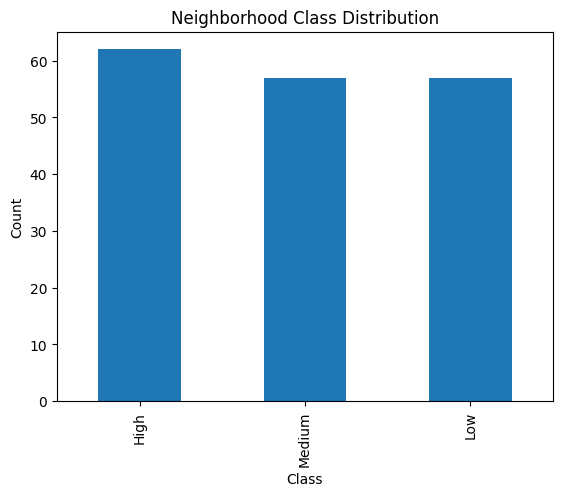

In [ ]:
import matplotlib.pyplot as plt

df_neigh["neighborhood_class"].value_counts().plot(kind="bar")
plt.title("Neighborhood Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

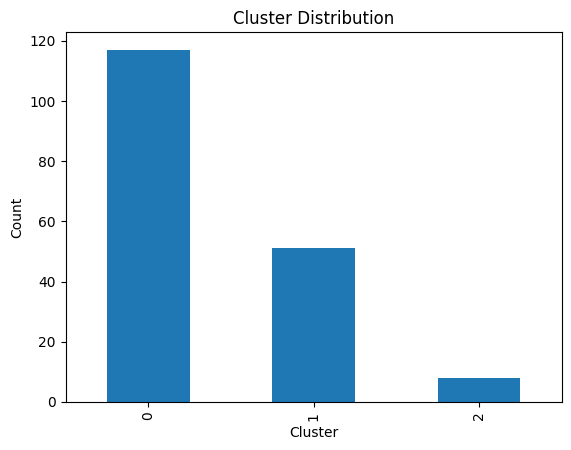

In [ ]:
df_neigh["cluster"].value_counts().sort_index().plot(kind="bar")
plt.title("Cluster Distribution")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.show()

In [ ]:
df_neigh.groupby("cluster")[[
    "services_score",
    "transport_score",
    "connectivity_score_scaled",
    "price_score",
    "final_score"
]].mean()

,services_score,transport_score,connectivity_score_scaled,price_score,final_score
cluster,,,,,
0,0.077800,0.122514,0.473272,0.743768,0.269096
1,0.108616,0.208044,1.000000,0.812502,0.466305
2,0.020325,0.012074,0.437500,0.246984,0.166493


In [ ]:
features = [
    "services_score",
    "transport_score",
    "connectivity_score_scaled",
    "price_score",
    "area",
    "lat",
    "lng"
]

In [ ]:
df_neigh[df_neigh["final_score"].isna()][[
    "neighborhood",
    "services_score",
    "transport_score",
    "connectivity_score_scaled",
    "price_score",
    "final_score"
]]

,neighborhood,services_score,transport_score,connectivity_score_scaled,price_score,final_score
134,Imam Muhammed Bin Saud Islamic University,0.031944,0.2625,0.624277,0.798345,NaN
141,King Abdullah City For Energy,0.195270,0.0000,0.624277,0.755349,NaN
145,King Khalid International Airport,0.310778,0.4000,0.624277,0.799131,NaN


In [ ]:
df_neigh = df_neigh.dropna(subset=[
    "services_score",
    "transport_score",
    "connectivity_score_scaled",
    "price_score",
    "final_score"
])

In [ ]:
from sklearn.ensemble import RandomForestRegressor

X = df_neigh[features]
y = df_neigh["final_score"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

reg_model = RandomForestRegressor(random_state=42)
reg_model.fit(X_train, y_train)

y_pred = reg_model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
print(mse)

0.00035853925548026195


In [ ]:
import numpy as np

rmse = np.sqrt(mse)
print(rmse)

0.018935132835030812


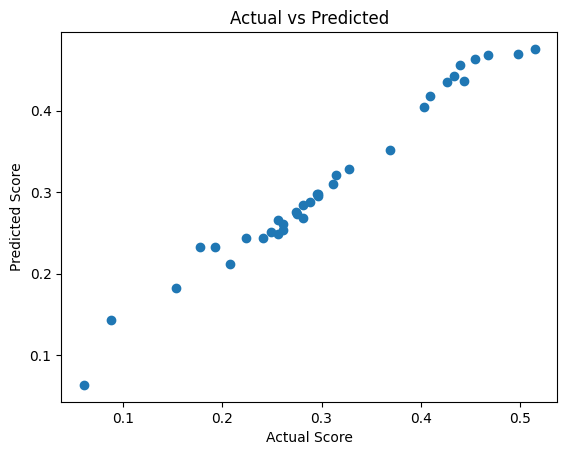

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs Predicted")
plt.show()